In [1]:
import pybamm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy import constants
from pybamm import Scalar

current_directory = os.getcwd()

parameter_values = pybamm.ParameterValues("OKane2022") # "lithium plating": "partially reversible",
options = {"thermal": "lumped","lithium plating": "irreversible","SEI":"ec reaction limited", "SEI film resistance":"average", "SEI porosity change": "true","loss of active material": "stress-driven","particle mechanics":"swelling only"} #"lithium plating": "irreversible",

model = pybamm.lithium_ion.SPM(options=options)

In [2]:
# %load std500cycles_tuneparameters.py
#Parameters tuned for 500 cycles standard
parameter_values.update({"Total heat transfer coefficient [W.m-2.K-1]": 10.0,})
#thermal parameters update
parameter_values.update({"Negative electrode OCP entropic change [V.K-1]": -0.0002,
                         "Positive electrode OCP entropic change [V.K-1]": -0.0004,
                         "Contact resistance [Ohm]": 0.001,
                        })
def ec_diffusivity(T_amb):
    D_sj = 2.5e-22*4*10*3*2 
    EaD = 10000
    arrhenius = np.exp(EaD / pybamm.constants.R *(1/ 298.15 - 1/ T_amb))
    return D_sj * arrhenius


parameter_values.update({"EC diffusivity [m2.s-1]": ec_diffusivity})
#sei parameters update
parameter_values.update({"SEI kinetic rate constant [m.s-1]": 1e-12*0.002*0.5}) 
parameter_values.update({"SEI growth activation energy [J.mol-1]": 48000.0,
                         "SEI partial molar volume [m3.mol-1]": 9.585e-05*0.4,
                         "SEI resistivity [Ohm.m]": 200000.0
                         })  
# LAM parameters update

parameter_values.update({"Positive electrode LAM constant proportional term [s-1]": 0.1*0.5*1.5/3600,
                         "Negative electrode LAM constant proportional term [s-1]": 0.2*0.5*1.5/3600,
                         
                         "Positive electrode LAM constant exponential term": 2.0*1.1,
                         "Negative electrode LAM constant exponential term": 2.0*1.1,
                         
                         })





#Plating paremeters update
parameter_values.update({
                        "Lithium plating kinetic rate constant [m.s-1]": 1e-09*0.001,
                        
                        })


In [3]:
current_directory

'/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip'

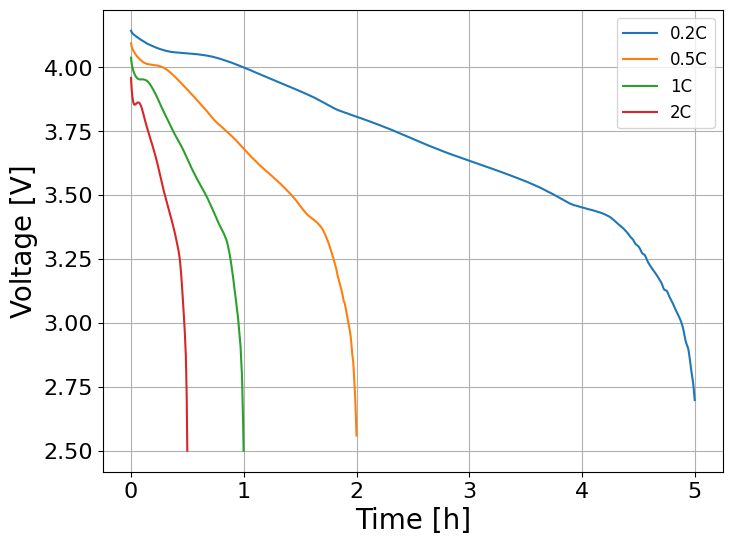

In [12]:
colors = ("r", "g", "b", "m")
plt.figure(figsize=(8,6))

def LG_M50_model(discharge): 
    
    model = pybamm.lithium_ion.DFN(options=options)
    sim = pybamm.Simulation(model=model, parameter_values=parameter_values, C_rate=discharge)
    sim.solve([0, 3600/discharge])
    return(
        sim.solution["Time [h]"].entries,
        #sim.solution["Discharge capacity [A.h]"].entries,
        sim.solution["Terminal voltage [V]"].entries
        )
 
    
for discharge in [0.2, 0.5, 1, 2]:
    
    model = LG_M50_model(discharge)
    plt.plot(*model,  linestyle="-", label=f"{discharge}C")
    


plt.xlabel("Time [h]",fontsize=20)
#plt.xlabel("Discharge capacity [A.h]", fontsize=20)
plt.ylabel("Voltage [V]", fontsize=20)
plt.legend(fontsize=12)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)

plt.show()

In [327]:
# plt.rc('font', size=14)          # default text
# plt.rc('axes', titlesize=16)     # title
# plt.rc('axes', labelsize=14)     # axis labels
# plt.rc('xtick', labelsize=12)    # x tick labels
# plt.rc('ytick', labelsize=12)    # y tick labels
# plt.rc('legend', fontsize=12)    # legend
# pybamm.dynamic_plot(
#     sim1,
#     output_variables =[
        
#         "Terminal voltage [V]",
#         "Current [A]",
#         "X-averaged cell temperature [K]",
        
#     ])

In [328]:
# t1 = sim1.solution["Time [h]"].entries
# Vc1 = sim1.solution["Terminal voltage [V]"].entries
# Temp1 = sim1.solution["X-averaged cell temperature [K]"].entries

# plt.plot(t1, Vc1)
# plt.show()
# plt.plot(t1, Temp1)